# Metodologia passo a passo (MLBatLife)

Este notebook segue a metodologia do trabalho, desde a carga dos dados ate a geracao das figuras utilizadas no artigo.

## Etapas
1. Carregamento do perfil de potencia residual (CSV).
2. Analise exploratoria e verificacao basica dos dados.
3. Extracao de variaveis diarias (T1 e T4).
4. Estimativa de SOH com modelo Random Forest pre-treinado.
5. Geracao de figuras para o artigo.
6. Salvamento de resultados para uso no texto e tabelas.

In [4]:
from pathlib import Path
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path(r"c:/Users/vdmas/OneDrive/FAESA/Trabalho de Conclusao de Curso")
MLBAT_DIR = (BASE_DIR / "code" / "MLBatLife").resolve()
DATA_PATH = BASE_DIR / "code" / "data" / "input_profile_sample.csv"
OUT_DIR = BASE_DIR / "pic"
OUT_DIR.mkdir(parents=True, exist_ok=True)

import sys
if str(MLBAT_DIR) not in sys.path:
    sys.path.insert(0, str(MLBAT_DIR))

import MLBatLife_Pred as blp

plt.rcParams.update({"figure.dpi": 120})

In [5]:
# 1) Carregamento do CSV
df = pd.read_csv(DATA_PATH)
df.head()

,Time,Power
0,0.0,0.000000
1,1.0,246.158968
2,2.0,244.609103
3,3.0,243.547783
4,4.0,763.679055


In [6]:
# 2) Verificacao basica
df.describe()

,Time,Power
count,2.628000e+06,2.628000e+06
mean,1.314000e+06,5.691696e+01
std,7.586384e+05,1.230175e+03
min,0.000000e+00,-4.894291e+03
25%,6.569998e+05,-1.693382e+02
50%,1.314000e+06,1.556772e+02
75%,1.970999e+06,4.201145e+02
max,2.627999e+06,1.846765e+04


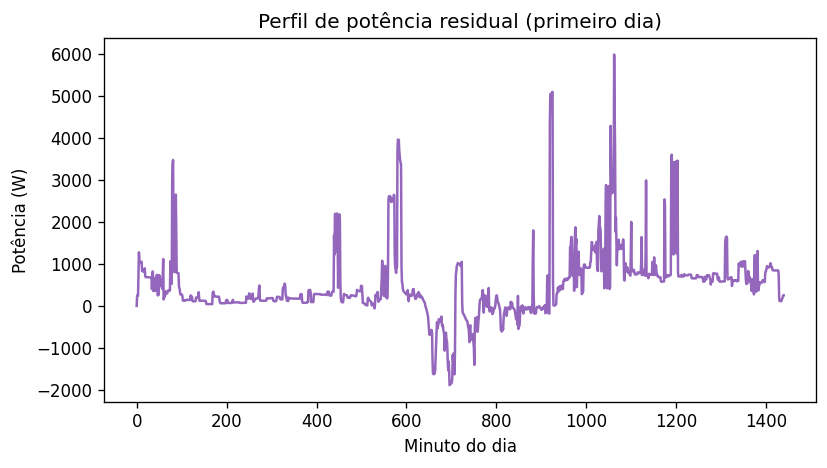

In [16]:
# 3) Perfil de potência residual (primeiro dia)
minutes_per_day = 24 * 60
first_day_profile = df["Power"].values[:minutes_per_day]

plt.figure(figsize=(7.0, 4.0))
plt.plot(np.arange(minutes_per_day), first_day_profile, color="#9467bd")
plt.xlabel("Minuto do dia")
plt.ylabel("Potência (W)")
plt.title("Perfil de potência residual (primeiro dia)")
plt.tight_layout()
plt.savefig(OUT_DIR / "input_profile_first_day.png", dpi=300)
plt.show()

In [17]:
# 4) Extracao de variaveis diarias (T1 e T4)
m_time, input_prof = blp.read_csv(str(DATA_PATH))
features, day = blp.extract_features(m_time, input_prof)

features_df = pd.DataFrame({
    "T1 (média)": features[:, 0],
    "T4 (média abs.)": features[:, 1],
    "Dia": day,
})
features_df.head()

,T1 (média),T4 (média abs.),Dia
0,491.157331,623.514492,0.0
1,820.284011,820.897951,1.0
2,742.346253,791.686974,2.0
3,656.796066,657.664798,3.0
4,661.846232,688.742303,4.0


In [10]:
# 5) Estimativa do SOH com modelo pre-treinado
strategy = 0  # 0: Greedy, 1: FeedInDamp
Qnom = 5      # kWh
os.chdir(MLBAT_DIR)
soh_hat = blp.estimate_soh(features, day, strategy, Qnom)

soh_daily = pd.DataFrame({"Dia": day, "SOH_est": soh_hat})
soh_daily.to_csv(OUT_DIR / "soh_daily.csv", index=False)
soh_daily.head()

c:\Users\vdmas\OneDrive\FAESA\Trabalho de Conclusao de Curso\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.4.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\vdmas\OneDrive\FAESA\Trabalho de Conclusao de Curso\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.4.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,Dia,SOH_est
0,0.0,1.000000
1,1.0,0.997376
2,2.0,0.997123
3,3.0,0.996900
4,4.0,0.996717


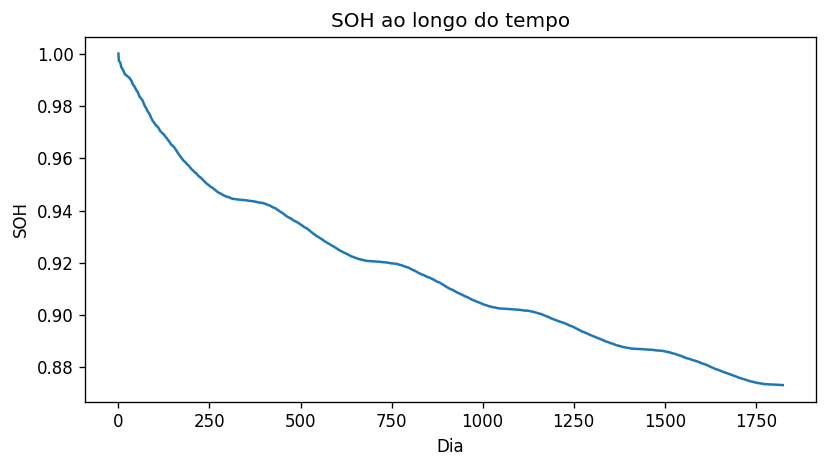

In [11]:
# 6) Grafico: SOH ao longo do tempo
plt.figure(figsize=(7.0, 4.0))
plt.plot(day, soh_hat, color="#1f77b4")
plt.xlabel("Dia")
plt.ylabel("SOH")
plt.title("SOH ao longo do tempo")
plt.tight_layout()
plt.savefig(OUT_DIR / "soh_over_time.png", dpi=300)
plt.show()

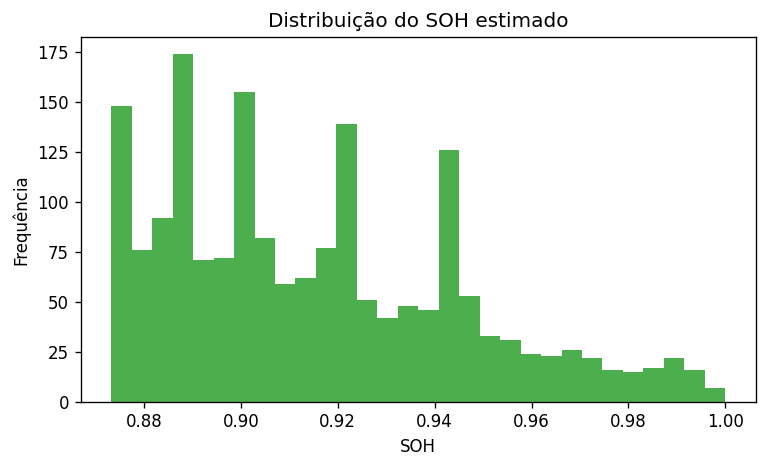

In [18]:
# 7) Grafico: distribuicao do SOH
plt.figure(figsize=(6.5, 4.0))
plt.hist(soh_hat, bins=30, color="#2ca02c", alpha=0.85)
plt.xlabel("SOH")
plt.ylabel("Frequência")
plt.title("Distribuição do SOH estimado")
plt.tight_layout()
plt.savefig(OUT_DIR / "soh_distribution.png", dpi=300)
plt.show()

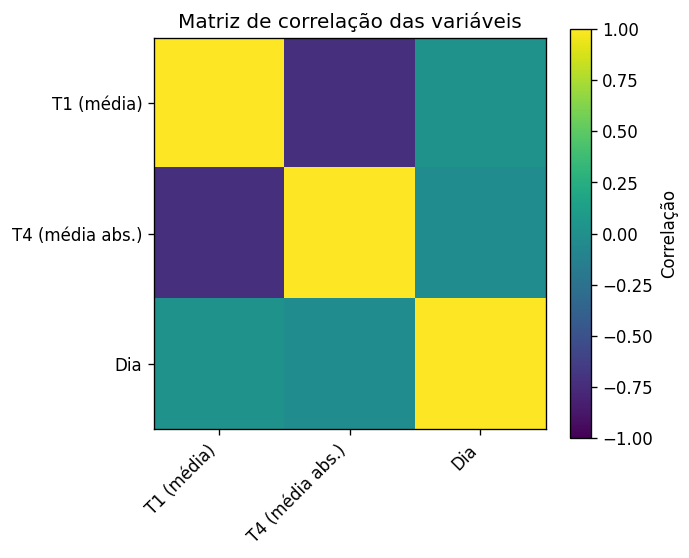

In [19]:
# 8) Matriz de correlacao das variaveis
corr = features_df.corr(numeric_only=True)
plt.figure(figsize=(5.8, 4.8))
plt.imshow(corr.values, cmap="viridis", vmin=-1, vmax=1)
plt.colorbar(label="Correlação")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlação das variáveis")
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_correlation.png", dpi=300)
plt.show()

c:\Users\vdmas\OneDrive\FAESA\Trabalho de Conclusao de Curso\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.4.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\vdmas\OneDrive\FAESA\Trabalho de Conclusao de Curso\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.4.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


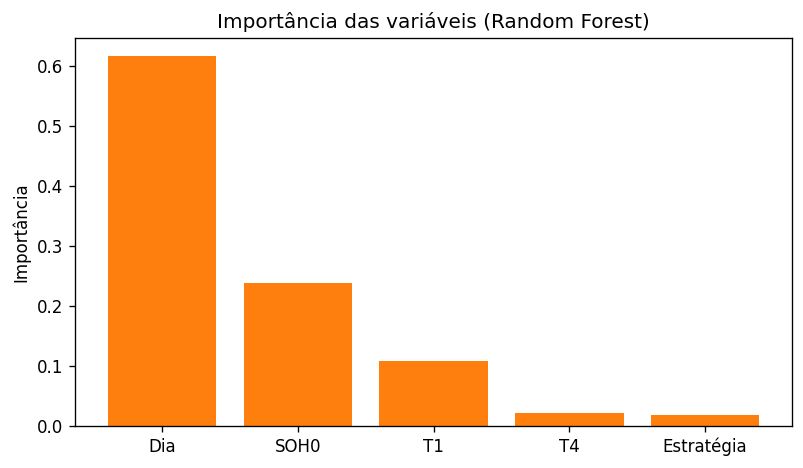

In [20]:
# 9) Importancia das variaveis (Random Forest)
with open(MLBAT_DIR / "MLBatLife_Model.pkl", "rb") as f:
    model, mu, sigma, qtr = pickle.load(f)

feature_names = ["SOH0", "T1", "Estratégia", "T4", "Dia"]
importances = getattr(model, "feature_importances_", None)

if importances is not None:
    order = np.argsort(importances)[::-1]
    plt.figure(figsize=(6.8, 4.0))
    plt.bar([feature_names[i] for i in order], importances[order], color="#ff7f0e")
    plt.ylabel("Importância")
    plt.title("Importância das variáveis (Random Forest)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "feature_importance.png", dpi=300)
    plt.show()

In [21]:
# 10) Resumo do SOH para referencia no texto
summary = pd.DataFrame({
    "métrica": ["min", "max", "média", "std", "final"],
    "valor": [
        float(np.min(soh_hat)),
        float(np.max(soh_hat)),
        float(np.mean(soh_hat)),
        float(np.std(soh_hat)),
        float(soh_hat[-1]),
    ],
})
summary.to_csv(OUT_DIR / "soh_summary.csv", index=False)
summary

,métrica,valor
0,min,0.873256
1,max,1.000000
2,média,0.915486
3,std,0.030566
4,final,0.873256
